In [1]:
import os, cv2, json, glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import sys, gc
sys.path.append("..")
from Network.index import ModelNetwork
from utils.index import showTile, faciesCmaps

In [2]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

gc.collect()
print(torch.__version__)              # versão do PyTorch
print(torch.cuda.is_available())      # True se detectou a GPU
print(torch.cuda.get_device_name(0))  # nome da GPU

2.7.1+cu118
True
Quadro P6000


In [3]:
models = [f'model_{i}' for i in sorted([int(path.split('_')[-1]) for path in os.listdir('Backup')])]
models = [f'model_0']
models 

['model_0']

In [4]:
modelId = models[-1]   # models[-1]
dataset = 'facies'

baseDir    = f'Backup/{modelId}'
datasetDir = f'../Dataset/{dataset}'
print(baseDir)

if not os.path.exists(baseDir):
    print(f"Error: Model {modelId} not found at {baseDir}")

if not os.path.exists(datasetDir):
    print(f"Error: Dataset {dataset} not found at {datasetDir}")

Backup/model_0


In [5]:
with open(f'{baseDir}/info.json', 'r', encoding='utf-8') as f:
    modelInfo = json.load(f)

modelOptions = modelInfo.get('model', {})
print("Model Options:")
print(json.dumps(modelOptions, indent=4))

network   = ModelNetwork(**modelOptions)
modelData = torch.load(f'{baseDir}/model.pth')

network.model.load_state_dict(modelData['model'])
network.model.eval()
print(f"Weights from {modelId} loaded successfully!")

Model Options:
{
    "network": "resaceunet",
    "img_size": [
        4,
        256,
        256
    ],
    "classes": 6,
    "channels": 1,
    "dropout": 0.05,
    "num_filters": 32,
    "lr": 0.0005,
    "deep_supervision": false
}
Weights from model_0 loaded successfully!


In [6]:
STEP = modelInfo['processing'].get('step')
STEP

3

In [7]:
imgPaths  = sorted(glob.glob(f'{datasetDir}/tiles/images/*.npy'))
maskPaths = sorted(glob.glob(f'{datasetDir}/tiles/masks/*.npy'))

if len(imgPaths) == 0 or len(maskPaths) == 0:
    print(f"No data found at {datasetDir}/tiles/images or masks.")

dfPredict = pd.DataFrame({
    'img_path': imgPaths,
    'mask_path': maskPaths
})
print(f"Total samples in {dataset}: {len(dfPredict)}")

Total samples in facies: 135


In [8]:
class PredictDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row  = self.df.iloc[index]
        img  = np.load(row.img_path).astype(np.float32)
        mask = np.load(row.mask_path).astype(np.float32)

        img_tensor  = torch.tensor(img,  dtype=torch.float32).unsqueeze(0)
        mask_tensor = torch.tensor(mask, dtype=torch.long).unsqueeze(0)
        return (img_tensor, mask_tensor)


predictDataset = PredictDataset(dfPredict)
predictLoader  = DataLoader(
    predictDataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

In [9]:
from torchmetrics.classification import MulticlassJaccardIndex

def computeIoU(network, loader):
    network.model.eval()
    network.iou.reset()
    perClass = MulticlassJaccardIndex(num_classes=network.classes, average='none').to(network.device) if network.multiclass else None

    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="Computing IoU"):
            imgs, masks = imgs.to(network.device), masks.to(network.device)
            logits = network.model(imgs)

            if network.multiclass:
                preds  = torch.argmax(logits, dim=1)
                target = masks.squeeze(1) if masks.dim() == 5 else masks
                network.iou.update(preds, target)
                perClass.update(preds, target)
            else:
                preds = (torch.sigmoid(logits) > 0.5)
                network.iou.update(preds, masks.int())

    iouValue = network.iou.compute().item()
    if perClass is not None:
        for c, v in enumerate(perClass.compute().tolist()):
            print(f"  IoU classe {c}: {v:.4f}")   # inclui a classe 0
    return iouValue


totalIoU = computeIoU(network, predictLoader)
print(f"\nMean IoU on {dataset}: {totalIoU:.4f}")

Computing IoU:   1%|          | 1/135 [00:11<24:37, 11.02s/it]


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 GiB. GPU 0 has a total capacity of 23.86 GiB of which 1.41 GiB is free. Including non-PyTorch memory, this process has 22.19 GiB memory in use. Of the allocated memory 18.59 GiB is allocated by PyTorch, and 3.40 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

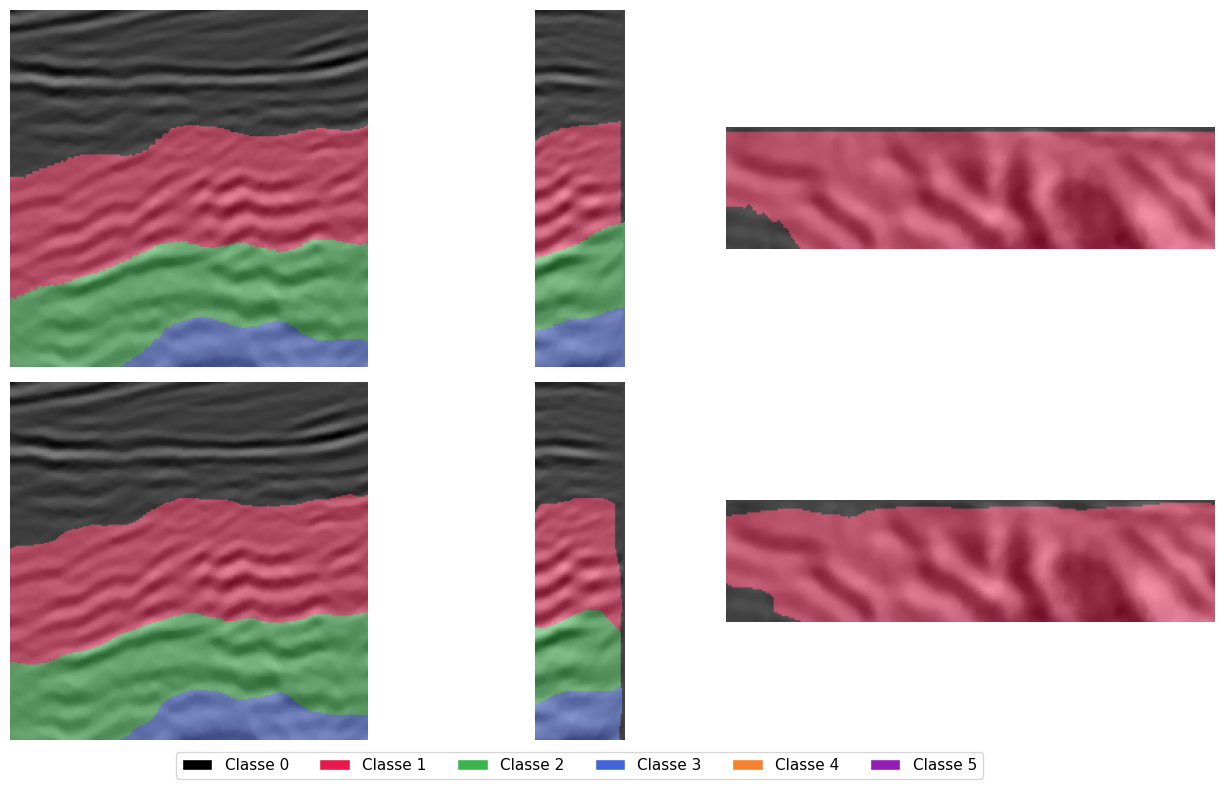

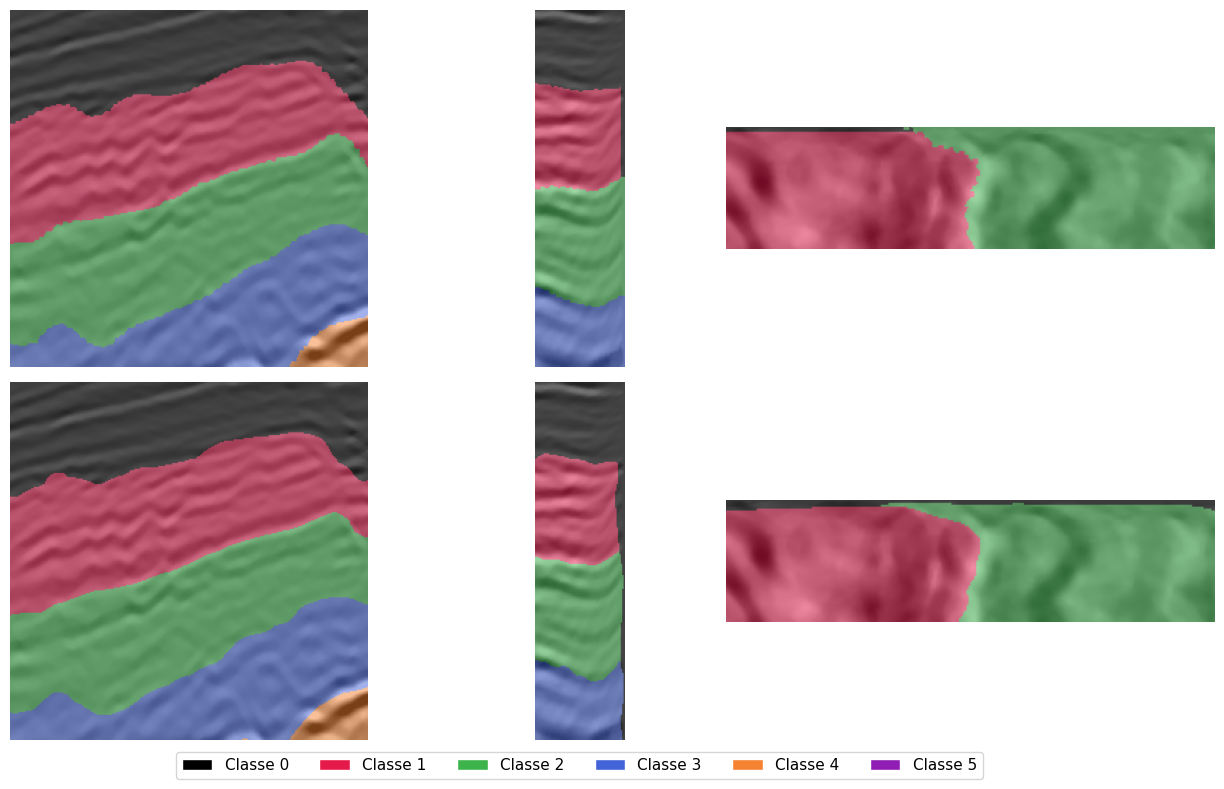

In [ ]:
def plotPrediction(index, dataset=predictDataset, network=network, alpha=0.5, savePath=None):
    img_tensor, mask_tensor = dataset[index]
    network.model.eval()

    with torch.no_grad():
        img_batch = img_tensor.unsqueeze(0).to(network.device)
        logits    = network.model(img_batch)
        pred = torch.argmax(logits, dim=1).squeeze() if network.multiclass else (torch.sigmoid(logits) > 0.5).squeeze().int()

    img_np  = img_tensor.squeeze().cpu().numpy()
    mask_np = mask_tensor.squeeze().cpu().numpy()
    pred_np = pred.cpu().numpy()

    if network.multiclass:
        solid_cmap, cmap = faciesCmaps(network.classes)
        mx, my, mz = img_np.shape[0] // 2, img_np.shape[1] // 2, img_np.shape[2] // 2
        planes = lambda v: [np.array(v[mx, :, :]), np.rot90(np.array(v[:, :, mz]), -1), np.array(v[:, my, :])]
        ig, mg, pg = planes(img_np), planes(mask_np), planes(pred_np)

        fig, axes = plt.subplots(2, 3, figsize=(13, 8))
        for j in range(3):
            for r, layer in enumerate([mg, pg]):
                axes[r, j].imshow(ig[j], cmap='gray')
                axes[r, j].imshow(layer[j], cmap=cmap, vmin=0, vmax=network.classes - 1, alpha=alpha)
                axes[r, j].axis('off')
                
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=solid_cmap.colors[i], edgecolor='white', label=f'Classe {i}') for i in range(network.classes)]
        fig.legend(handles=legend_elements, loc='lower center', ncol=min(network.classes, 7), bbox_to_anchor=(0.5, 0.01), fontsize=11)
        
        plt.tight_layout(rect=[0, 0.05, 1, 1])
        if savePath:
            plt.savefig(savePath, bbox_inches='tight', dpi=200); plt.close(fig)
        else:
            plt.show()
        return

    imgNorm = cv2.normalize(img_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    imgRgb  = np.stack((imgNorm, imgNorm, imgNorm), axis=-1)
    overlay = imgRgb.copy()
    is_gt   = (mask_np > 0)
    is_pred = (pred_np > 0)
    inters  = (is_gt & is_pred)

    overlay[is_gt]   = [0, 0, 255]
    overlay[is_pred] = [255, 0, 0]
    overlay[inters]  = [0, 255, 0]

    result = (imgRgb * (1 - alpha) + overlay * alpha).astype(np.uint8)
    showTile(img=result, save=savePath)


for i in range(min(len(predictDataset), 2)):
    plotPrediction(index=i)

# PREDIÇÃO DO VOLUME INTEIRO

In [ ]:
class PredictBuilder:
    def __init__(self, target_size, classes, save_path=None):
        self.tz, self.ty, self.tx = target_size
        self.classes   = classes
        self.save_path = save_path

    def process(self, vol):
        pads = [(0, (s - vol.shape[i] % s) % s) for i, s in enumerate((self.tz, self.ty, self.tx))]
        if all(p == 0 for _, p in pads): return vol
        return np.pad(vol, pads, mode='reflect')

    def update(self):
        network.model.eval()
        self.pred  = np.zeros(seismic.shape, dtype=np.uint8)
        self.inter = np.zeros(self.classes, dtype=np.int64)
        self.union = np.zeros(self.classes, dtype=np.int64)

        for z in tqdm(range(0, seismic.shape[0], self.tz)):
            if z % STEP == 0:
                continue

            src = np.asarray(seismic[z:z + self.tz], dtype=np.float32)
            if src.shape[0] == 0: break

            img = self.process(src)
            res = np.zeros(img.shape, dtype=np.uint8)

            for y in range(0, img.shape[1], self.ty):
                for x in range(0, img.shape[2], self.tx):
                    it = img[:, y:y + self.ty, x:x + self.tx]

                    imgTensor = torch.tensor(it).unsqueeze(0).unsqueeze(0).to(network.device)
                    with torch.no_grad():
                        logits = network.model(imgTensor)
                        pred = torch.argmax(logits, dim=1).squeeze(0).squeeze(0) if network.multiclass else (torch.sigmoid(logits) > 0.5).squeeze(0).squeeze(0).int()

                    res[:, y:y + self.ty, x:x + self.tx] = pred.cpu().numpy()

            orig_z = src.shape[0]
            block  = res[:orig_z, :seismic.shape[1], :seismic.shape[2]]
            self.pred[z:z + orig_z] = block

            # iou incremental do volume inteiro (inclui a classe 0)
            gt = np.asarray(masks[z:z + orig_z]).astype(np.uint8)
            for c in range(self.classes):
                pm, gm = (block == c), (gt == c)
                self.inter[c] += np.count_nonzero(pm & gm)
                self.union[c] += np.count_nonzero(pm | gm)

        if self.save_path:
            np.save(self.save_path, self.pred)

    def iou(self):
        vals = self.inter / np.maximum(self.union, 1)
        data = {str(c): float(v) for c, v in enumerate(vals)}
        data['mean'] = float(vals.mean())
        return data


RAW_DIR      = f'{datasetDir}/files/'
SEISMIC_PATH = os.path.join(RAW_DIR, 'marlim_norm_perc_1-99_cut.npy')
MASK_PATH    = os.path.join(RAW_DIR, 'npy_multiclass_cut.npy')
SAVE_PRED    = False   # opcional: salva predicted.npy (~3.5 GB) no backup

seismic = np.load(SEISMIC_PATH, mmap_mode='r')
masks   = np.load(MASK_PATH, mmap_mode='r')

builder = PredictBuilder(network.img_size, network.classes, save_path=os.path.join(baseDir, 'predicted.npy') if SAVE_PRED else None)
builder.update()
builder.pred.shape

100%|██████████| 785/785 [20:28<00:00,  1.56s/it]


(3137, 552, 2050)

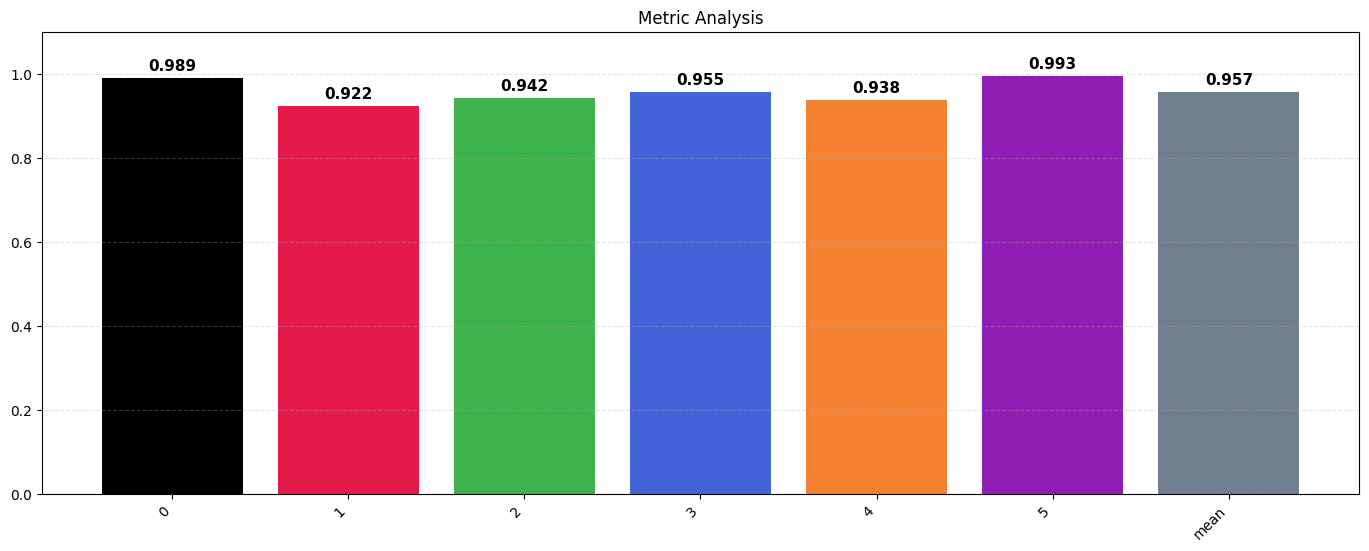

In [ ]:
from utils.Plotter.index import Plotter

marlimIoU = builder.iou()
modelInfo['marlim_iou'] = marlimIoU

with open(f'{baseDir}/info.json', 'w', encoding='utf-8') as f:
    json.dump(modelInfo, f, ensure_ascii=False, indent=4)

# Gráfico por classe do bloco inteiro (ordenado por índice da classe: 0 a N, 'mean' no final)
class_keys = sorted([k for k in marlimIoU.keys() if k != 'mean'], key=lambda x: int(x) if x.isdigit() else x)
ious = {k: marlimIoU[k] for k in class_keys}
if 'mean' in marlimIoU:
    ious['mean'] = marlimIoU['mean']

plt.figure(figsize=(17, 6))
Plotter(ious)
plt.savefig(os.path.join(baseDir, 'marlim_classes.png'))
plt.show()

# COMPARAÇÃO VISUAL

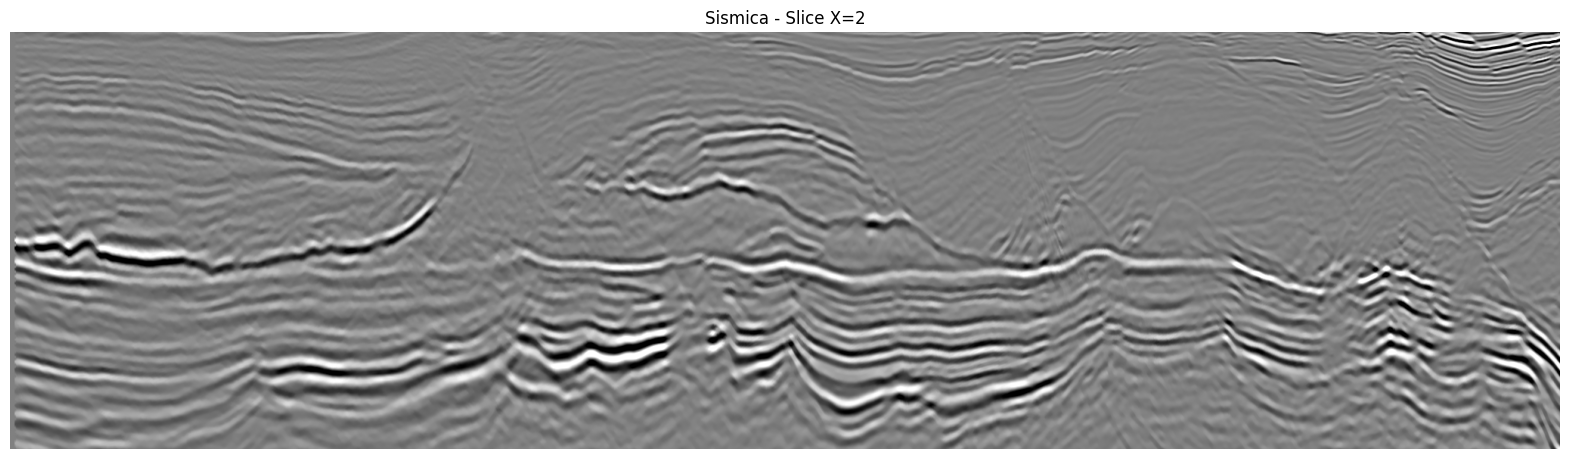

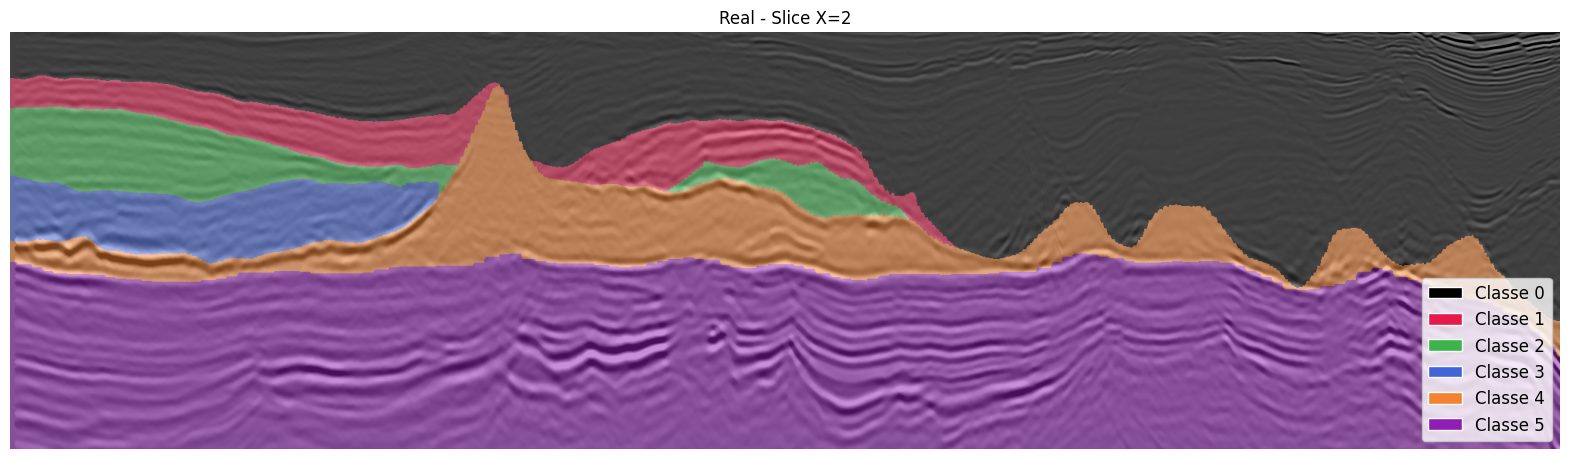

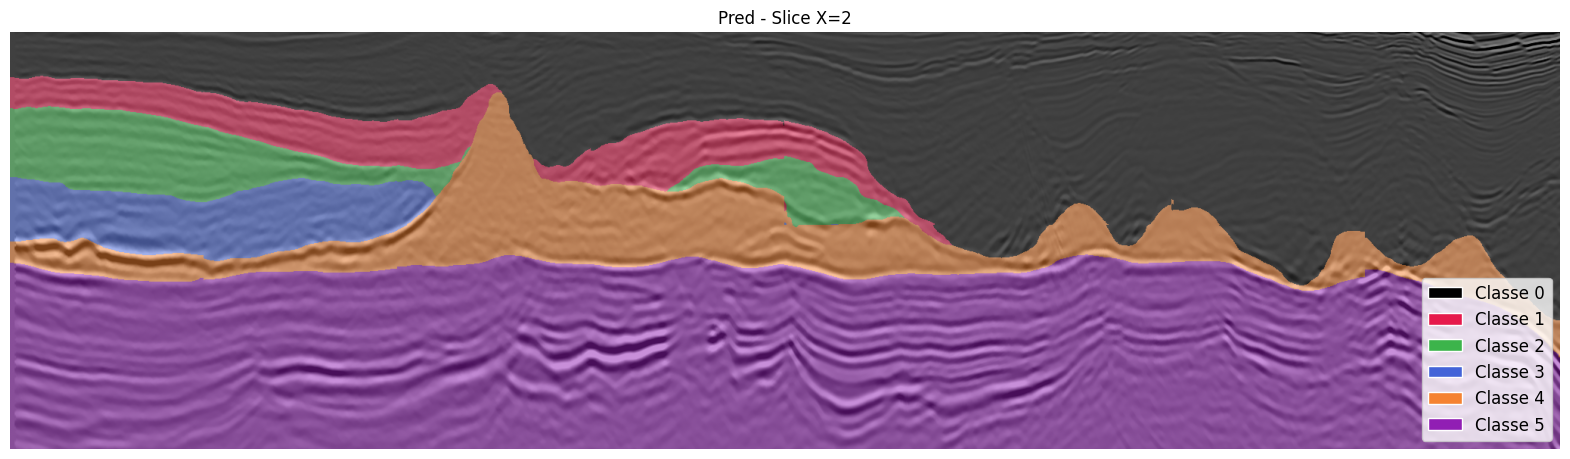

In [ ]:
def plotViews(img, mask, pred, alpha=0.5, saveDir=None):
    from matplotlib.patches import Patch
    mx = img.shape[0] // 2
    ig = np.array(img[mx, :, :])
    mg = np.array(mask[mx, :, :])
    pg = np.array(pred[mx, :, :])
    solid_cmap, cmap = faciesCmaps(network.classes)

    for name, layer in [('sismica', None), ('real', mg), ('pred', pg)]:
        plt.figure(figsize=(20, 10))
        plt.imshow(ig, cmap='gray')

        if layer is not None:
            plt.imshow(layer, cmap=cmap, vmin=0, vmax=network.classes - 1, alpha=alpha)
            legend_elements = [Patch(facecolor=solid_cmap.colors[i], edgecolor='white', label=f'Classe {i}') for i in range(network.classes)]
            plt.legend(handles=legend_elements, loc='lower right', fontsize=12)

        plt.title(f"{name.capitalize()} - Slice X={mx}"); plt.axis('off')
        if saveDir:
            plt.savefig(os.path.join(saveDir, f'volume_{name}.png'), dpi=200, bbox_inches='tight')
        plt.show()


viewsDir = os.path.join(baseDir, 'views')
os.makedirs(viewsDir, exist_ok=True)

ix   = (seismic.shape[0] // 2)
img  = np.asarray(seismic[ix:ix+4], dtype=np.float32)
mask = np.asarray(masks[ix:ix+4], dtype=np.uint8)
pred = builder.pred[ix:ix+4]
plotViews(img, mask, pred, saveDir=viewsDir)